# Project 1: Do Large Daily Crypto Sell-Offs Lead To Short-Term Mean Reversion?

Research Question:
When BTC, ETH, and SOL fall by 10% or more in one day, what happens over the next 1, 3, 7, and 30 days?

Hypothesis:
Large crypto sell-offs may be followed by short-term rebounds.

## Project Summary

This project analyses whether BTC, ETH and SOL show short-term mean reversion after large daily sell-offs. The study compares forward returns after -10% daily declines, tests whether results improve when the asset remains above its 50-day moving average, and checks whether deeper sell-off thresholds produce stronger rebounds.

The main finding is that BTC appears more reliable for short-term rebounds, SOL offers stronger upside but much greater downside risk, and ETH appears weaker under this framework.

## Note On Crypto Daily Close

Crypto trades 24/7, so there is no official market close like there is for equities. In this project, “Close” refers to the end-of-day price provided by the data source. The analysis therefore uses daily close-to-close returns based on the data provider’s candle convention, most likely UTC daily candles. This is a limitation because different daily cut-off times could slightly change which sell-off events are identified.

## Data Setup

This section installs the required library, imports Python packages, and downloads daily price data for BTC, ETH and SOL using yfinance.

## BTC Analysis

This section analyses BTC sell-offs of 10% or more and calculates forward returns over 1-day, 3-day, 7-day and 30-day horizons.

In [ ]:
!pip install yfinance

In [2]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
btc = yf.download("BTC-USD", start="2017-01-01")

In [4]:
btc.columns = btc.columns.get_level_values(0)

In [5]:
btc["Daily Return"] = btc["Close"].pct_change()

In [6]:
btc_large_drops = btc[btc["Daily Return"] <= -0.10]

In [7]:
btc["Forward 1D Return"] = btc["Close"].shift(-1) / btc["Close"] - 1
btc["Forward 3D Return"] = btc["Close"].shift(-3) / btc["Close"] - 1
btc["Forward 7D Return"] = btc["Close"].shift(-7) / btc["Close"] - 1
btc["Forward 30D Return"] = btc["Close"].shift(-30) / btc["Close"] - 1

In [8]:
btc_large_drops = btc[btc["Daily Return"] <= -0.10]

In [9]:
forward_return_columns = [
    "Forward 1D Return",
    "Forward 3D Return",
    "Forward 7D Return",
    "Forward 30D Return"
]

btc_average_returns = btc_large_drops[forward_return_columns].mean()

In [10]:
btc_win_rates = (btc_large_drops[forward_return_columns] > 0).mean()

In [11]:
btc_worst_returns = btc_large_drops[forward_return_columns].min()
btc_best_returns = btc_large_drops[forward_return_columns].max()

In [12]:
btc_summary = pd.DataFrame({
    "Average Return": btc_average_returns,
    "Win Rate": btc_win_rates,
    "Worst Return": btc_worst_returns,
    "Best Return": btc_best_returns
})

In [13]:
btc_summary_percent = btc_summary * 100

In [14]:
btc_summary_percent = btc_summary_percent.round(2)

btc_summary_percent

,Average Return,Win Rate,Worst Return,Best Return
Price,,,,
Forward 1D Return,2.35,68.57,-14.35,15.30
Forward 3D Return,1.42,57.14,-12.62,18.84
Forward 7D Return,1.98,57.14,-24.72,40.59
Forward 30D Return,9.23,54.29,-35.69,116.38


In [15]:
btc_number_of_large_drops = len(btc_large_drops)

## ETH Analysis

This section repeats the same large sell-off analysis for Ethereum. The aim is to test whether ETH shows stronger or weaker mean reversion than BTC after falling by 10% or more in one day.

In [ ]:
eth = yf.download("ETH-USD", start="2017-01-01")

In [17]:
eth.columns = eth.columns.get_level_values(0)

In [18]:
eth["Daily Return"] = eth["Close"].pct_change()

In [19]:
eth["Forward 1D Return"] = eth["Close"].shift(-1) / eth["Close"] - 1
eth["Forward 3D Return"] = eth["Close"].shift(-3) / eth["Close"] - 1
eth["Forward 7D Return"] = eth["Close"].shift(-7) / eth["Close"] - 1
eth["Forward 30D Return"] = eth["Close"].shift(-30) / eth["Close"] - 1

In [20]:
eth_large_drops = eth[eth["Daily Return"] <= -0.10]

In [21]:
eth_number_of_large_drops = len(eth_large_drops)

In [22]:
eth_average_returns = eth_large_drops[forward_return_columns].mean()
eth_win_rates = (eth_large_drops[forward_return_columns] > 0).mean()
eth_worst_returns = eth_large_drops[forward_return_columns].min()
eth_best_returns = eth_large_drops[forward_return_columns].max()

eth_summary = pd.DataFrame({
    "Average Return": eth_average_returns,
    "Win Rate": eth_win_rates,
    "Worst Return": eth_worst_returns,
    "Best Return": eth_best_returns
})

eth_summary_percent = (eth_summary * 100).round(2)

eth_summary_percent

,Average Return,Win Rate,Worst Return,Best Return
Price,,,,
Forward 1D Return,1.70,59.32,-17.46,18.56
Forward 3D Return,1.59,54.24,-23.79,24.08
Forward 7D Return,0.29,44.07,-37.61,27.93
Forward 30D Return,2.05,37.29,-53.52,77.13


## SOL Analysis

This section repeats the same large sell-off analysis for Solana. The aim is to test whether SOL, as a higher-beta crypto asset, shows stronger rebounds or greater downside risk after falling by 10% or more in one day.

In [ ]:
sol = yf.download("SOL-USD", start="2017-01-01")

In [24]:
sol.columns = sol.columns.get_level_values(0)

In [25]:
sol["Daily Return"] = sol["Close"].pct_change()

In [26]:
sol["Forward 1D Return"] = sol["Close"].shift(-1) / sol["Close"] - 1
sol["Forward 3D Return"] = sol["Close"].shift(-3) / sol["Close"] - 1
sol["Forward 7D Return"] = sol["Close"].shift(-7) / sol["Close"] - 1
sol["Forward 30D Return"] = sol["Close"].shift(-30) / sol["Close"] - 1

In [27]:
sol_large_drops = sol[sol["Daily Return"] <= -0.10]

In [28]:
sol_number_of_large_drops = len(sol_large_drops)

In [29]:
sol_average_returns = sol_large_drops[forward_return_columns].mean()
sol_win_rates = (sol_large_drops[forward_return_columns] > 0).mean()
sol_worst_returns = sol_large_drops[forward_return_columns].min()
sol_best_returns = sol_large_drops[forward_return_columns].max()

sol_summary = pd.DataFrame({
    "Average Return": sol_average_returns,
    "Win Rate": sol_win_rates,
    "Worst Return": sol_worst_returns,
    "Best Return": sol_best_returns
})

sol_summary_percent = (sol_summary * 100).round(2)

sol_summary_percent

,Average Return,Win Rate,Worst Return,Best Return
Price,,,,
Forward 1D Return,2.22,58.82,-42.28,47.28
Forward 3D Return,5.23,66.18,-57.35,75.48
Forward 7D Return,5.34,60.29,-59.72,82.14
Forward 30D Return,20.07,42.65,-56.28,264.93


## BTC, ETH And SOL Comparison

This section compares the large sell-off results across BTC, ETH and SOL to identify which asset showed the strongest evidence of short-term mean reversion after a -10% daily fall.

In [30]:
large_drop_counts = pd.DataFrame({
    "Asset": ["BTC", "ETH", "SOL"],
    "Number Of -10% Daily Drops": [
        btc_number_of_large_drops,
        eth_number_of_large_drops,
        sol_number_of_large_drops
    ]
})

large_drop_counts

,Asset,Number Of -10% Daily Drops
0,BTC,35
1,ETH,59
2,SOL,68


In [31]:
full_comparison = pd.DataFrame({
    "Asset": ["BTC", "ETH", "SOL"],

    "Number Of -10% Drops": [
        btc_number_of_large_drops,
        eth_number_of_large_drops,
        sol_number_of_large_drops
    ],

    "Avg 1D Return": [
        btc_summary_percent.loc["Forward 1D Return", "Average Return"],
        eth_summary_percent.loc["Forward 1D Return", "Average Return"],
        sol_summary_percent.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        btc_summary_percent.loc["Forward 1D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 1D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 1D Return", "Win Rate"]
    ],

    "Avg 3D Return": [
        btc_summary_percent.loc["Forward 3D Return", "Average Return"],
        eth_summary_percent.loc["Forward 3D Return", "Average Return"],
        sol_summary_percent.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        btc_summary_percent.loc["Forward 3D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 3D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 3D Return", "Win Rate"]
    ],

    "Avg 7D Return": [
        btc_summary_percent.loc["Forward 7D Return", "Average Return"],
        eth_summary_percent.loc["Forward 7D Return", "Average Return"],
        sol_summary_percent.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        btc_summary_percent.loc["Forward 7D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 7D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 7D Return", "Win Rate"]
    ],

    "Avg 30D Return": [
        btc_summary_percent.loc["Forward 30D Return", "Average Return"],
        eth_summary_percent.loc["Forward 30D Return", "Average Return"],
        sol_summary_percent.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        btc_summary_percent.loc["Forward 30D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 30D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 30D Return", "Win Rate"]
    ]
})

full_comparison

,Asset,Number Of -10% Drops,Avg 1D Return,1D Win Rate,Avg 3D Return,3D Win Rate,Avg 7D Return,7D Win Rate,Avg 30D Return,30D Win Rate
0,BTC,35,2.35,68.57,1.42,57.14,1.98,57.14,9.23,54.29
1,ETH,59,1.70,59.32,1.59,54.24,0.29,44.07,2.05,37.29
2,SOL,68,2.22,58.82,5.23,66.18,5.34,60.29,20.07,42.65


## Visualising 1-Day Mean Reversion

This chart compares the average 1-day forward return after -10% daily sell-offs across BTC, ETH and SOL.

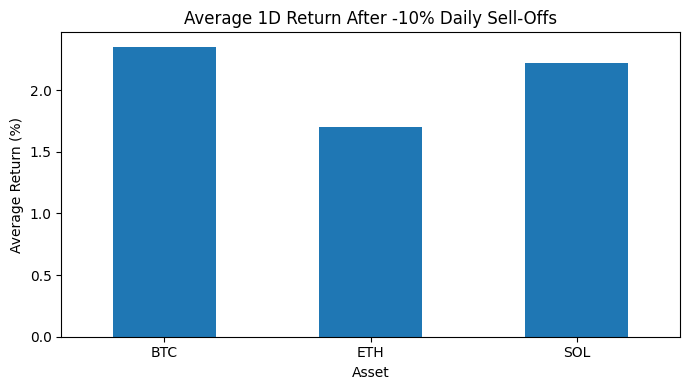

In [32]:
full_comparison.set_index("Asset")["Avg 1D Return"].plot(kind="bar", figsize=(7, 4))

plt.title("Average 1D Return After -10% Daily Sell-Offs")
plt.ylabel("Average Return (%)")
plt.xlabel("Asset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Initial Findings

The results suggest that large daily crypto sell-offs do not affect BTC, ETH, and SOL equally. BTC shows the most reliable short-term rebound based on the 1-day win rate, while SOL shows stronger average returns over 3-day and 7-day horizons. ETH appears weaker, particularly over 7-day and 30-day horizons.

SOL’s 30-day average return is the highest, but its win rate is below 50%, suggesting that the result is driven by a smaller number of very large rebounds rather than consistent performance. Therefore, SOL may offer higher upside after major sell-offs, but with substantially greater downside and lower reliability.

In [33]:
full_comparison_with_risk = pd.DataFrame({
    "Asset": ["BTC", "ETH", "SOL"],

    "Number Of -10% Drops": [
        btc_number_of_large_drops,
        eth_number_of_large_drops,
        sol_number_of_large_drops
    ],

    "Avg 1D Return": [
        btc_summary_percent.loc["Forward 1D Return", "Average Return"],
        eth_summary_percent.loc["Forward 1D Return", "Average Return"],
        sol_summary_percent.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        btc_summary_percent.loc["Forward 1D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 1D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 1D Return", "Win Rate"]
    ],

    "Worst 1D Return": [
        btc_summary_percent.loc["Forward 1D Return", "Worst Return"],
        eth_summary_percent.loc["Forward 1D Return", "Worst Return"],
        sol_summary_percent.loc["Forward 1D Return", "Worst Return"]
    ],

    "Avg 3D Return": [
        btc_summary_percent.loc["Forward 3D Return", "Average Return"],
        eth_summary_percent.loc["Forward 3D Return", "Average Return"],
        sol_summary_percent.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        btc_summary_percent.loc["Forward 3D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 3D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 3D Return", "Win Rate"]
    ],

    "Worst 3D Return": [
        btc_summary_percent.loc["Forward 3D Return", "Worst Return"],
        eth_summary_percent.loc["Forward 3D Return", "Worst Return"],
        sol_summary_percent.loc["Forward 3D Return", "Worst Return"]
    ],

    "Avg 7D Return": [
        btc_summary_percent.loc["Forward 7D Return", "Average Return"],
        eth_summary_percent.loc["Forward 7D Return", "Average Return"],
        sol_summary_percent.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        btc_summary_percent.loc["Forward 7D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 7D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 7D Return", "Win Rate"]
    ],

    "Worst 7D Return": [
        btc_summary_percent.loc["Forward 7D Return", "Worst Return"],
        eth_summary_percent.loc["Forward 7D Return", "Worst Return"],
        sol_summary_percent.loc["Forward 7D Return", "Worst Return"]
    ],

    "Avg 30D Return": [
        btc_summary_percent.loc["Forward 30D Return", "Average Return"],
        eth_summary_percent.loc["Forward 30D Return", "Average Return"],
        sol_summary_percent.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        btc_summary_percent.loc["Forward 30D Return", "Win Rate"],
        eth_summary_percent.loc["Forward 30D Return", "Win Rate"],
        sol_summary_percent.loc["Forward 30D Return", "Win Rate"]
    ],

    "Worst 30D Return": [
        btc_summary_percent.loc["Forward 30D Return", "Worst Return"],
        eth_summary_percent.loc["Forward 30D Return", "Worst Return"],
        sol_summary_percent.loc["Forward 30D Return", "Worst Return"]
    ]
})

full_comparison_with_risk

,Asset,Number Of -10% Drops,Avg 1D Return,1D Win Rate,Worst 1D Return,Avg 3D Return,3D Win Rate,Worst 3D Return,Avg 7D Return,7D Win Rate,Worst 7D Return,Avg 30D Return,30D Win Rate,Worst 30D Return
0,BTC,35,2.35,68.57,-14.35,1.42,57.14,-12.62,1.98,57.14,-24.72,9.23,54.29,-35.69
1,ETH,59,1.70,59.32,-17.46,1.59,54.24,-23.79,0.29,44.07,-37.61,2.05,37.29,-53.52
2,SOL,68,2.22,58.82,-42.28,5.23,66.18,-57.35,5.34,60.29,-59.72,20.07,42.65,-56.28


## Risk-Adjusted Comparison

Adding worst-case outcomes changes the interpretation of the results. BTC appears to have the cleanest 1-day mean-reversion profile after -10% daily sell-offs, with the highest 1-day win rate and less severe downside than ETH or SOL.

SOL shows the strongest 3-day and 7-day rebound profile, with both higher average returns and higher win rates than BTC and ETH. However, SOL also has extremely severe worst-case losses, especially over 3-day and 7-day horizons. This suggests that SOL may offer stronger upside after large sell-offs, but only with substantially greater downside risk.

ETH appears weakest under this simple rule, particularly over 7-day and 30-day horizons, where win rates fall below 50%.

Overall, the results suggest that large crypto sell-offs may create short-term mean-reversion opportunities, but the attractiveness of the setup depends heavily on the asset and holding period. BTC appears more reliable, SOL appears higher-upside but much riskier, and ETH appears less favourable under this basic framework.

## Trend Filter Analysis

Research Question:
Do large daily crypto sell-offs produce better forward returns when the asset remains above its 50-day moving average?

Hypothesis:
Large sell-offs may be more attractive when they occur during broader uptrends, because the move may represent a temporary shakeout rather than the start of a deeper downtrend.

Method:
For each asset, I calculate the 50-day moving average and only keep -10% daily sell-off events where the closing price is above the 50-day moving average. I then compare the forward 1D, 3D, 7D, and 30D returns against the original unfiltered results.

In [34]:
btc["50D Moving Average"] = btc["Close"].rolling(window=50).mean()

In [35]:
btc["Above 50D Moving Average"] = btc["Close"] > btc["50D Moving Average"]

In [36]:
btc_uptrend_large_drops = btc[
    (btc["Daily Return"] <= -0.10) &
    (btc["Above 50D Moving Average"] == True)
]

In [37]:
btc_uptrend_number_of_large_drops = len(btc_uptrend_large_drops)

In [38]:
btc_uptrend_average_returns = btc_uptrend_large_drops[forward_return_columns].mean()
btc_uptrend_win_rates = (btc_uptrend_large_drops[forward_return_columns] > 0).mean()
btc_uptrend_worst_returns = btc_uptrend_large_drops[forward_return_columns].min()
btc_uptrend_best_returns = btc_uptrend_large_drops[forward_return_columns].max()

btc_uptrend_summary = pd.DataFrame({
    "Average Return": btc_uptrend_average_returns,
    "Win Rate": btc_uptrend_win_rates,
    "Worst Return": btc_uptrend_worst_returns,
    "Best Return": btc_uptrend_best_returns
})

btc_uptrend_summary_percent = (btc_uptrend_summary * 100).round(2)

btc_uptrend_summary_percent

,Average Return,Win Rate,Worst Return,Best Return
Price,,,,
Forward 1D Return,5.70,83.33,-1.54,10.95
Forward 3D Return,1.18,50.00,-7.33,15.67
Forward 7D Return,8.02,83.33,-2.63,35.32
Forward 30D Return,7.16,33.33,-16.13,81.99


In [39]:
btc_original_vs_uptrend = pd.DataFrame({
    "Original Avg Return": btc_summary_percent["Average Return"],
    "Original Win Rate": btc_summary_percent["Win Rate"],
    "Uptrend Avg Return": btc_uptrend_summary_percent["Average Return"],
    "Uptrend Win Rate": btc_uptrend_summary_percent["Win Rate"],
    "Original Worst Return": btc_summary_percent["Worst Return"],
    "Uptrend Worst Return": btc_uptrend_summary_percent["Worst Return"]
})

btc_original_vs_uptrend

,Original Avg Return,Original Win Rate,Uptrend Avg Return,Uptrend Win Rate,Original Worst Return,Uptrend Worst Return
Price,,,,,,
Forward 1D Return,2.35,68.57,5.70,83.33,-14.35,-1.54
Forward 3D Return,1.42,57.14,1.18,50.00,-12.62,-7.33
Forward 7D Return,1.98,57.14,8.02,83.33,-24.72,-2.63
Forward 30D Return,9.23,54.29,7.16,33.33,-35.69,-16.13


### BTC Trend Filter Interpretation

The trend filter tests whether BTC sell-offs behave differently when BTC remains above its 50-day moving average. This helps distinguish between buying a dip in an existing uptrend and buying into a potential breakdown.

The filtered sample size is important. If only a small number of events remain, the results should be interpreted cautiously.

Compared with the original BTC results, the uptrend-filtered results show whether the 50-day moving average improves average forward returns, win rates, and downside risk.

### ETH Trend Filter Analysis

This section applies the 50-day moving average trend filter to ETH. The aim is to test whether ETH sell-offs perform better when ETH remains above its 50-day moving average, compared with the original unfiltered ETH results.

In [40]:
eth["50D Moving Average"] = eth["Close"].rolling(window=50).mean()

In [41]:
eth["Above 50D Moving Average"] = eth["Close"] > eth["50D Moving Average"]

In [42]:
eth_uptrend_large_drops = eth[
    (eth["Daily Return"] <= -0.10) &
    (eth["Above 50D Moving Average"] == True)
]

In [43]:
eth_uptrend_number_of_large_drops = len(eth_uptrend_large_drops)

In [44]:
eth_uptrend_average_returns = eth_uptrend_large_drops[forward_return_columns].mean()
eth_uptrend_win_rates = (eth_uptrend_large_drops[forward_return_columns] > 0).mean()
eth_uptrend_worst_returns = eth_uptrend_large_drops[forward_return_columns].min()
eth_uptrend_best_returns = eth_uptrend_large_drops[forward_return_columns].max()

eth_uptrend_summary = pd.DataFrame({
    "Average Return": eth_uptrend_average_returns,
    "Win Rate": eth_uptrend_win_rates,
    "Worst Return": eth_uptrend_worst_returns,
    "Best Return": eth_uptrend_best_returns
})

eth_uptrend_summary_percent = (eth_uptrend_summary * 100).round(2)

eth_uptrend_summary_percent

,Average Return,Win Rate,Worst Return,Best Return
Price,,,,
Forward 1D Return,2.17,57.14,-4.28,11.27
Forward 3D Return,1.25,50.00,-9.12,24.08
Forward 7D Return,0.02,42.86,-36.90,18.81
Forward 30D Return,3.87,35.71,-30.24,71.15


In [45]:
eth_original_vs_uptrend = pd.DataFrame({
    "Original Avg Return": eth_summary_percent["Average Return"],
    "Original Win Rate": eth_summary_percent["Win Rate"],
    "Uptrend Avg Return": eth_uptrend_summary_percent["Average Return"],
    "Uptrend Win Rate": eth_uptrend_summary_percent["Win Rate"],
    "Original Worst Return": eth_summary_percent["Worst Return"],
    "Uptrend Worst Return": eth_uptrend_summary_percent["Worst Return"]
})

eth_original_vs_uptrend

,Original Avg Return,Original Win Rate,Uptrend Avg Return,Uptrend Win Rate,Original Worst Return,Uptrend Worst Return
Price,,,,,,
Forward 1D Return,1.70,59.32,2.17,57.14,-17.46,-4.28
Forward 3D Return,1.59,54.24,1.25,50.00,-23.79,-9.12
Forward 7D Return,0.29,44.07,0.02,42.86,-37.61,-36.90
Forward 30D Return,2.05,37.29,3.87,35.71,-53.52,-30.24


### ETH Trend Filter Interpretation

The 50-day moving average trend filter does not appear to materially improve ETH’s sell-off behaviour. While the 1-day average return improves slightly from the original result, the win rate does not improve. The 3-day and 7-day results remain weak, and the 30-day win rate remains below 50%.

This suggests that, unlike BTC, ETH does not show a clearly stronger mean-reversion pattern after -10% daily sell-offs simply because it remains above its 50-day moving average. The filter may reduce some downside risk, but the overall setup remains less attractive than BTC under this framework.

### SOL Trend Filter Analysis

This section applies the 50-day moving average trend filter to SOL. The aim is to test whether SOL sell-offs perform better when SOL remains above its 50-day moving average, compared with the original unfiltered SOL results.

This is especially important because SOL is more volatile than BTC and ETH. A -10% daily fall may be more common for SOL, so the trend filter may help distinguish between a temporary pullback in an uptrend and a more dangerous breakdown.

In [46]:
sol["50D Moving Average"] = sol["Close"].rolling(window=50).mean()

In [47]:
sol["Above 50D Moving Average"] = sol["Close"] > sol["50D Moving Average"]

In [48]:
sol_uptrend_large_drops = sol[
    (sol["Daily Return"] <= -0.10) &
    (sol["Above 50D Moving Average"] == True)
]

In [49]:
sol_uptrend_number_of_large_drops = len(sol_uptrend_large_drops)

In [50]:
sol_uptrend_average_returns = sol_uptrend_large_drops[forward_return_columns].mean()
sol_uptrend_win_rates = (sol_uptrend_large_drops[forward_return_columns] > 0).mean()
sol_uptrend_worst_returns = sol_uptrend_large_drops[forward_return_columns].min()
sol_uptrend_best_returns = sol_uptrend_large_drops[forward_return_columns].max()

sol_uptrend_summary = pd.DataFrame({
    "Average Return": sol_uptrend_average_returns,
    "Win Rate": sol_uptrend_win_rates,
    "Worst Return": sol_uptrend_worst_returns,
    "Best Return": sol_uptrend_best_returns
})

sol_uptrend_summary_percent = (sol_uptrend_summary * 100).round(2)

sol_uptrend_summary_percent

,Average Return,Win Rate,Worst Return,Best Return
Price,,,,
Forward 1D Return,3.78,68.42,-19.32,22.99
Forward 3D Return,9.52,78.95,-57.35,75.48
Forward 7D Return,13.35,68.42,-59.72,82.14
Forward 30D Return,65.17,57.89,-56.28,264.93


In [51]:
sol_original_vs_uptrend = pd.DataFrame({
    "Original Avg Return": sol_summary_percent["Average Return"],
    "Original Win Rate": sol_summary_percent["Win Rate"],
    "Uptrend Avg Return": sol_uptrend_summary_percent["Average Return"],
    "Uptrend Win Rate": sol_uptrend_summary_percent["Win Rate"],
    "Original Worst Return": sol_summary_percent["Worst Return"],
    "Uptrend Worst Return": sol_uptrend_summary_percent["Worst Return"]
})

sol_original_vs_uptrend

,Original Avg Return,Original Win Rate,Uptrend Avg Return,Uptrend Win Rate,Original Worst Return,Uptrend Worst Return
Price,,,,,,
Forward 1D Return,2.22,58.82,3.78,68.42,-42.28,-19.32
Forward 3D Return,5.23,66.18,9.52,78.95,-57.35,-57.35
Forward 7D Return,5.34,60.29,13.35,68.42,-59.72,-59.72
Forward 30D Return,20.07,42.65,65.17,57.89,-56.28,-56.28


### SOL Trend Filter Interpretation

The 50-day moving average trend filter appears to materially improve SOL’s sell-off behaviour. Compared with the original unfiltered results, the uptrend-filtered results show higher average returns and stronger win rates across all horizons.

The improvement is particularly clear over the 3-day and 7-day horizons, where SOL’s average returns and win rates both increase meaningfully. The 30-day result also improves substantially, with the average return rising sharply and the win rate moving above 50%.

However, the worst-case returns remain severe, especially over the 3-day, 7-day, and 30-day horizons. This suggests that while SOL may offer stronger upside after large sell-offs during uptrends, the strategy would still require strict risk management and careful position sizing.

Overall, SOL appears to respond well to the 50-day moving average filter, but its extreme downside risk means the result should not be interpreted as a simple low-risk buy signal.

## BTC, ETH And SOL Uptrend Comparison

This section compares BTC, ETH and SOL after applying the 50-day moving average trend filter. The aim is to identify which asset showed the strongest mean-reversion behaviour after a -10% daily sell-off while still trading above its 50-day moving average.

In [52]:
uptrend_comparison = pd.DataFrame({
    "Asset": ["BTC", "ETH", "SOL"],

    "Uptrend -10% Drops": [
        btc_uptrend_number_of_large_drops,
        eth_uptrend_number_of_large_drops,
        sol_uptrend_number_of_large_drops
    ],

    "Avg 1D Return": [
        btc_uptrend_summary_percent.loc["Forward 1D Return", "Average Return"],
        eth_uptrend_summary_percent.loc["Forward 1D Return", "Average Return"],
        sol_uptrend_summary_percent.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        btc_uptrend_summary_percent.loc["Forward 1D Return", "Win Rate"],
        eth_uptrend_summary_percent.loc["Forward 1D Return", "Win Rate"],
        sol_uptrend_summary_percent.loc["Forward 1D Return", "Win Rate"]
    ],

    "Worst 1D Return": [
        btc_uptrend_summary_percent.loc["Forward 1D Return", "Worst Return"],
        eth_uptrend_summary_percent.loc["Forward 1D Return", "Worst Return"],
        sol_uptrend_summary_percent.loc["Forward 1D Return", "Worst Return"]
    ],

    "Avg 3D Return": [
        btc_uptrend_summary_percent.loc["Forward 3D Return", "Average Return"],
        eth_uptrend_summary_percent.loc["Forward 3D Return", "Average Return"],
        sol_uptrend_summary_percent.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        btc_uptrend_summary_percent.loc["Forward 3D Return", "Win Rate"],
        eth_uptrend_summary_percent.loc["Forward 3D Return", "Win Rate"],
        sol_uptrend_summary_percent.loc["Forward 3D Return", "Win Rate"]
    ],

    "Worst 3D Return": [
        btc_uptrend_summary_percent.loc["Forward 3D Return", "Worst Return"],
        eth_uptrend_summary_percent.loc["Forward 3D Return", "Worst Return"],
        sol_uptrend_summary_percent.loc["Forward 3D Return", "Worst Return"]
    ],

    "Avg 7D Return": [
        btc_uptrend_summary_percent.loc["Forward 7D Return", "Average Return"],
        eth_uptrend_summary_percent.loc["Forward 7D Return", "Average Return"],
        sol_uptrend_summary_percent.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        btc_uptrend_summary_percent.loc["Forward 7D Return", "Win Rate"],
        eth_uptrend_summary_percent.loc["Forward 7D Return", "Win Rate"],
        sol_uptrend_summary_percent.loc["Forward 7D Return", "Win Rate"]
    ],

    "Worst 7D Return": [
        btc_uptrend_summary_percent.loc["Forward 7D Return", "Worst Return"],
        eth_uptrend_summary_percent.loc["Forward 7D Return", "Worst Return"],
        sol_uptrend_summary_percent.loc["Forward 7D Return", "Worst Return"]
    ],

    "Avg 30D Return": [
        btc_uptrend_summary_percent.loc["Forward 30D Return", "Average Return"],
        eth_uptrend_summary_percent.loc["Forward 30D Return", "Average Return"],
        sol_uptrend_summary_percent.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        btc_uptrend_summary_percent.loc["Forward 30D Return", "Win Rate"],
        eth_uptrend_summary_percent.loc["Forward 30D Return", "Win Rate"],
        sol_uptrend_summary_percent.loc["Forward 30D Return", "Win Rate"]
    ],

    "Worst 30D Return": [
        btc_uptrend_summary_percent.loc["Forward 30D Return", "Worst Return"],
        eth_uptrend_summary_percent.loc["Forward 30D Return", "Worst Return"],
        sol_uptrend_summary_percent.loc["Forward 30D Return", "Worst Return"]
    ]
})

uptrend_comparison

,Asset,Uptrend -10% Drops,Avg 1D Return,1D Win Rate,Worst 1D Return,Avg 3D Return,3D Win Rate,Worst 3D Return,Avg 7D Return,7D Win Rate,Worst 7D Return,Avg 30D Return,30D Win Rate,Worst 30D Return
0,BTC,6,5.70,83.33,-1.54,1.18,50.00,-7.33,8.02,83.33,-2.63,7.16,33.33,-16.13
1,ETH,14,2.17,57.14,-4.28,1.25,50.00,-9.12,0.02,42.86,-36.90,3.87,35.71,-30.24
2,SOL,19,3.78,68.42,-19.32,9.52,78.95,-57.35,13.35,68.42,-59.72,65.17,57.89,-56.28


## Visualising The 50-Day Moving Average Trend Filter

This chart compares the average 1-day forward return after -10% daily sell-offs when each asset remained above its 50-day moving average.

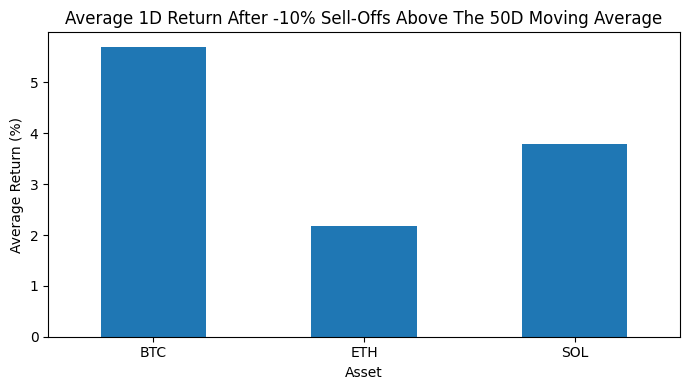

In [53]:
uptrend_comparison.set_index("Asset")["Avg 1D Return"].plot(kind="bar", figsize=(7, 4))

plt.title("Average 1D Return After -10% Sell-Offs Above The 50D Moving Average")
plt.ylabel("Average Return (%)")
plt.xlabel("Asset")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### Uptrend Comparison Interpretation

After applying the 50-day moving average trend filter, the results differ meaningfully across BTC, ETH and SOL.

BTC shows the cleanest short-term reliability, with strong 1-day and 7-day win rates and relatively limited worst-case downside. However, the filtered BTC sample contains only a small number of events, so the result should be treated as promising but preliminary.

ETH remains the weakest asset under this framework. The trend filter does not materially improve ETH’s win rates, particularly over the 7-day and 30-day horizons, where results remain poor.

SOL shows the strongest upside profile after -10% sell-offs during uptrends. Its 3-day, 7-day and 30-day average returns improve substantially, and win rates also improve compared with the unfiltered results. However, SOL continues to show extreme worst-case losses, meaning that any potential strategy based on this pattern would require strict risk management and careful position sizing.

Overall, the 50-day moving average filter appears useful for separating higher-quality sell-off events from weaker ones, especially for BTC and SOL. BTC appears more reliable but has a small sample size, while SOL appears higher-upside but significantly riskier. ETH appears less attractive under this framework.

## Threshold Sensitivity Analysis

Research Question:
Do larger daily crypto sell-offs produce stronger mean-reversion returns, or do they indicate deeper downside risk?

Hypothesis:
Larger sell-offs may produce stronger rebounds if they represent capitulation events. However, very large sell-offs may also signal more severe market stress, leading to weaker or more volatile forward returns.

Method:
This section compares forward returns after different daily sell-off thresholds: -10%, -15%, and -20%. The aim is to test whether the mean-reversion pattern becomes stronger or weaker as the sell-off threshold becomes more extreme.

In [54]:
def analyse_selloff_threshold(data, threshold):
    large_drops = data[data["Daily Return"] <= threshold]

    average_returns = large_drops[forward_return_columns].mean()
    win_rates = (large_drops[forward_return_columns] > 0).mean()
    worst_returns = large_drops[forward_return_columns].min()
    best_returns = large_drops[forward_return_columns].max()

    summary = pd.DataFrame({
        "Average Return": average_returns,
        "Win Rate": win_rates,
        "Worst Return": worst_returns,
        "Best Return": best_returns
    })

    summary_percent = (summary * 100).round(2)

    number_of_events = len(large_drops)

    return number_of_events, summary_percent

In [55]:
btc_10_events, btc_10_summary = analyse_selloff_threshold(btc, -0.10)
btc_15_events, btc_15_summary = analyse_selloff_threshold(btc, -0.15)
btc_20_events, btc_20_summary = analyse_selloff_threshold(btc, -0.20)

In [56]:
btc_threshold_comparison = pd.DataFrame({
    "Threshold": ["-10%", "-15%", "-20%"],

    "Number Of Events": [
        btc_10_events,
        btc_15_events,
        btc_20_events
    ],

    "Avg 1D Return": [
        btc_10_summary.loc["Forward 1D Return", "Average Return"],
        btc_15_summary.loc["Forward 1D Return", "Average Return"],
        btc_20_summary.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        btc_10_summary.loc["Forward 1D Return", "Win Rate"],
        btc_15_summary.loc["Forward 1D Return", "Win Rate"],
        btc_20_summary.loc["Forward 1D Return", "Win Rate"]
    ],

    "Avg 3D Return": [
        btc_10_summary.loc["Forward 3D Return", "Average Return"],
        btc_15_summary.loc["Forward 3D Return", "Average Return"],
        btc_20_summary.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        btc_10_summary.loc["Forward 3D Return", "Win Rate"],
        btc_15_summary.loc["Forward 3D Return", "Win Rate"],
        btc_20_summary.loc["Forward 3D Return", "Win Rate"]
    ],

    "Avg 7D Return": [
        btc_10_summary.loc["Forward 7D Return", "Average Return"],
        btc_15_summary.loc["Forward 7D Return", "Average Return"],
        btc_20_summary.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        btc_10_summary.loc["Forward 7D Return", "Win Rate"],
        btc_15_summary.loc["Forward 7D Return", "Win Rate"],
        btc_20_summary.loc["Forward 7D Return", "Win Rate"]
    ],

    "Avg 30D Return": [
        btc_10_summary.loc["Forward 30D Return", "Average Return"],
        btc_15_summary.loc["Forward 30D Return", "Average Return"],
        btc_20_summary.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        btc_10_summary.loc["Forward 30D Return", "Win Rate"],
        btc_15_summary.loc["Forward 30D Return", "Win Rate"],
        btc_20_summary.loc["Forward 30D Return", "Win Rate"]
    ]
})

btc_threshold_comparison

,Threshold,Number Of Events,Avg 1D Return,1D Win Rate,Avg 3D Return,3D Win Rate,Avg 7D Return,7D Win Rate,Avg 30D Return,30D Win Rate
0,-10%,35,2.35,68.57,1.42,57.14,1.98,57.14,9.23,54.29
1,-15%,5,6.97,60.00,6.51,80.00,10.84,60.00,28.89,60.00
2,-20%,1,11.93,100.00,8.48,100.00,24.55,100.00,37.99,100.00


### BTC Threshold Sensitivity Interpretation

The BTC threshold sensitivity results suggest that deeper daily sell-offs were followed by stronger average forward returns. The -15% and -20% thresholds show higher average returns than the -10% threshold across most horizons.

However, the sample size falls sharply as the threshold becomes more extreme. The -10% threshold contains 35 events, while the -15% threshold contains only 5 events and the -20% threshold contains only 1 event. This means the stronger results at deeper thresholds should be interpreted cautiously.

Overall, the BTC results are directionally interesting, but the -15% and -20% thresholds do not provide enough observations to draw strong conclusions.

### ETH Threshold Sensitivity Analysis

This section tests whether ETH behaves differently after increasingly large daily sell-offs. The aim is to compare ETH forward returns after -10%, -15%, and -20% daily declines.

In [57]:
eth_10_events, eth_10_summary = analyse_selloff_threshold(eth, -0.10)
eth_15_events, eth_15_summary = analyse_selloff_threshold(eth, -0.15)
eth_20_events, eth_20_summary = analyse_selloff_threshold(eth, -0.20)

In [58]:
eth_threshold_comparison = pd.DataFrame({
    "Threshold": ["-10%", "-15%", "-20%"],

    "Number Of Events": [
        eth_10_events,
        eth_15_events,
        eth_20_events
    ],

    "Avg 1D Return": [
        eth_10_summary.loc["Forward 1D Return", "Average Return"],
        eth_15_summary.loc["Forward 1D Return", "Average Return"],
        eth_20_summary.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        eth_10_summary.loc["Forward 1D Return", "Win Rate"],
        eth_15_summary.loc["Forward 1D Return", "Win Rate"],
        eth_20_summary.loc["Forward 1D Return", "Win Rate"]
    ],

    "Avg 3D Return": [
        eth_10_summary.loc["Forward 3D Return", "Average Return"],
        eth_15_summary.loc["Forward 3D Return", "Average Return"],
        eth_20_summary.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        eth_10_summary.loc["Forward 3D Return", "Win Rate"],
        eth_15_summary.loc["Forward 3D Return", "Win Rate"],
        eth_20_summary.loc["Forward 3D Return", "Win Rate"]
    ],

    "Avg 7D Return": [
        eth_10_summary.loc["Forward 7D Return", "Average Return"],
        eth_15_summary.loc["Forward 7D Return", "Average Return"],
        eth_20_summary.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        eth_10_summary.loc["Forward 7D Return", "Win Rate"],
        eth_15_summary.loc["Forward 7D Return", "Win Rate"],
        eth_20_summary.loc["Forward 7D Return", "Win Rate"]
    ],

    "Avg 30D Return": [
        eth_10_summary.loc["Forward 30D Return", "Average Return"],
        eth_15_summary.loc["Forward 30D Return", "Average Return"],
        eth_20_summary.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        eth_10_summary.loc["Forward 30D Return", "Win Rate"],
        eth_15_summary.loc["Forward 30D Return", "Win Rate"],
        eth_20_summary.loc["Forward 30D Return", "Win Rate"]
    ]
})

eth_threshold_comparison

,Threshold,Number Of Events,Avg 1D Return,1D Win Rate,Avg 3D Return,3D Win Rate,Avg 7D Return,7D Win Rate,Avg 30D Return,30D Win Rate
0,-10%,59,1.70,59.32,1.59,54.24,0.29,44.07,2.05,37.29
1,-15%,17,3.87,70.59,2.63,52.94,1.67,58.82,7.09,47.06
2,-20%,2,15.86,100.00,2.37,50.00,19.49,100.00,15.76,50.00


### ETH Threshold Sensitivity Interpretation

The ETH threshold sensitivity results suggest that deeper daily sell-offs produce stronger short-term mean-reversion behaviour than the basic -10% threshold. The -15% threshold shows a clear improvement in the 1-day average return and win rate, and the 7-day win rate also improves compared with the -10% result.

However, the sample size becomes smaller as the threshold becomes more extreme. The -20% threshold contains only 2 events, so the results at this level should not be treated as reliable evidence.

Overall, ETH appears more attractive after deeper sell-offs than after ordinary -10% sell-offs, but the evidence weakens at the most extreme threshold because of limited observations.

### SOL Threshold Sensitivity Analysis

This section tests whether SOL behaves differently after increasingly large daily sell-offs. The aim is to compare SOL forward returns after -10%, -15%, and -20% daily declines.

This is particularly important because SOL is more volatile than BTC and ETH, meaning a -10% daily fall may be less extreme for SOL than it is for BTC.

In [59]:
sol_10_events, sol_10_summary = analyse_selloff_threshold(sol, -0.10)
sol_15_events, sol_15_summary = analyse_selloff_threshold(sol, -0.15)
sol_20_events, sol_20_summary = analyse_selloff_threshold(sol, -0.20)

In [60]:
sol_threshold_comparison = pd.DataFrame({
    "Threshold": ["-10%", "-15%", "-20%"],

    "Number Of Events": [
        sol_10_events,
        sol_15_events,
        sol_20_events
    ],

    "Avg 1D Return": [
        sol_10_summary.loc["Forward 1D Return", "Average Return"],
        sol_15_summary.loc["Forward 1D Return", "Average Return"],
        sol_20_summary.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        sol_10_summary.loc["Forward 1D Return", "Win Rate"],
        sol_15_summary.loc["Forward 1D Return", "Win Rate"],
        sol_20_summary.loc["Forward 1D Return", "Win Rate"]
    ],

    "Avg 3D Return": [
        sol_10_summary.loc["Forward 3D Return", "Average Return"],
        sol_15_summary.loc["Forward 3D Return", "Average Return"],
        sol_20_summary.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        sol_10_summary.loc["Forward 3D Return", "Win Rate"],
        sol_15_summary.loc["Forward 3D Return", "Win Rate"],
        sol_20_summary.loc["Forward 3D Return", "Win Rate"]
    ],

    "Avg 7D Return": [
        sol_10_summary.loc["Forward 7D Return", "Average Return"],
        sol_15_summary.loc["Forward 7D Return", "Average Return"],
        sol_20_summary.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        sol_10_summary.loc["Forward 7D Return", "Win Rate"],
        sol_15_summary.loc["Forward 7D Return", "Win Rate"],
        sol_20_summary.loc["Forward 7D Return", "Win Rate"]
    ],

    "Avg 30D Return": [
        sol_10_summary.loc["Forward 30D Return", "Average Return"],
        sol_15_summary.loc["Forward 30D Return", "Average Return"],
        sol_20_summary.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        sol_10_summary.loc["Forward 30D Return", "Win Rate"],
        sol_15_summary.loc["Forward 30D Return", "Win Rate"],
        sol_20_summary.loc["Forward 30D Return", "Win Rate"]
    ]
})

sol_threshold_comparison

,Threshold,Number Of Events,Avg 1D Return,1D Win Rate,Avg 3D Return,3D Win Rate,Avg 7D Return,7D Win Rate,Avg 30D Return,30D Win Rate
0,-10%,68,2.22,58.82,5.23,66.18,5.34,60.29,20.07,42.65
1,-15%,22,6.91,77.27,2.64,59.09,3.81,63.64,19.48,36.36
2,-20%,9,11.30,77.78,6.11,66.67,7.65,66.67,28.18,55.56


### SOL Threshold Sensitivity Interpretation

The SOL threshold sensitivity results suggest that deeper daily sell-offs are followed by stronger short-term rebounds, particularly over the 1-day horizon. As the threshold becomes more extreme, the 1-day average return increases and the 1-day win rate also improves.

Unlike BTC and ETH, SOL still has a usable number of observations at the -20% threshold, reflecting its higher volatility. This makes deeper sell-off thresholds more informative for SOL than for BTC or ETH.

However, the longer-term results are more mixed. The 3-day, 7-day, and 30-day results do not improve consistently across every threshold, and the sample size still becomes smaller as the sell-off threshold becomes more extreme.

Overall, SOL appears to show stronger short-term mean reversion after deeper sell-offs, but the results remain volatile and should be interpreted with caution.

### Threshold Sensitivity Summary

This section summarises how BTC, ETH and SOL behave across different sell-off thresholds. The aim is to compare whether deeper sell-offs produce stronger mean-reversion behaviour, and whether the results remain reliable once sample size is considered.

In [61]:
threshold_summary = pd.DataFrame({
    "Asset": ["BTC", "BTC", "BTC", "ETH", "ETH", "ETH", "SOL", "SOL", "SOL"],

    "Threshold": ["-10%", "-15%", "-20%", "-10%", "-15%", "-20%", "-10%", "-15%", "-20%"],

    "Number Of Events": [
        btc_10_events,
        btc_15_events,
        btc_20_events,
        eth_10_events,
        eth_15_events,
        eth_20_events,
        sol_10_events,
        sol_15_events,
        sol_20_events
    ],

    "Avg 1D Return": [
        btc_10_summary.loc["Forward 1D Return", "Average Return"],
        btc_15_summary.loc["Forward 1D Return", "Average Return"],
        btc_20_summary.loc["Forward 1D Return", "Average Return"],
        eth_10_summary.loc["Forward 1D Return", "Average Return"],
        eth_15_summary.loc["Forward 1D Return", "Average Return"],
        eth_20_summary.loc["Forward 1D Return", "Average Return"],
        sol_10_summary.loc["Forward 1D Return", "Average Return"],
        sol_15_summary.loc["Forward 1D Return", "Average Return"],
        sol_20_summary.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        btc_10_summary.loc["Forward 1D Return", "Win Rate"],
        btc_15_summary.loc["Forward 1D Return", "Win Rate"],
        btc_20_summary.loc["Forward 1D Return", "Win Rate"],
        eth_10_summary.loc["Forward 1D Return", "Win Rate"],
        eth_15_summary.loc["Forward 1D Return", "Win Rate"],
        eth_20_summary.loc["Forward 1D Return", "Win Rate"],
        sol_10_summary.loc["Forward 1D Return", "Win Rate"],
        sol_15_summary.loc["Forward 1D Return", "Win Rate"],
        sol_20_summary.loc["Forward 1D Return", "Win Rate"]
    ],

    "Avg 3D Return": [
        btc_10_summary.loc["Forward 3D Return", "Average Return"],
        btc_15_summary.loc["Forward 3D Return", "Average Return"],
        btc_20_summary.loc["Forward 3D Return", "Average Return"],
        eth_10_summary.loc["Forward 3D Return", "Average Return"],
        eth_15_summary.loc["Forward 3D Return", "Average Return"],
        eth_20_summary.loc["Forward 3D Return", "Average Return"],
        sol_10_summary.loc["Forward 3D Return", "Average Return"],
        sol_15_summary.loc["Forward 3D Return", "Average Return"],
        sol_20_summary.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        btc_10_summary.loc["Forward 3D Return", "Win Rate"],
        btc_15_summary.loc["Forward 3D Return", "Win Rate"],
        btc_20_summary.loc["Forward 3D Return", "Win Rate"],
        eth_10_summary.loc["Forward 3D Return", "Win Rate"],
        eth_15_summary.loc["Forward 3D Return", "Win Rate"],
        eth_20_summary.loc["Forward 3D Return", "Win Rate"],
        sol_10_summary.loc["Forward 3D Return", "Win Rate"],
        sol_15_summary.loc["Forward 3D Return", "Win Rate"],
        sol_20_summary.loc["Forward 3D Return", "Win Rate"]
    ],

    "Avg 7D Return": [
        btc_10_summary.loc["Forward 7D Return", "Average Return"],
        btc_15_summary.loc["Forward 7D Return", "Average Return"],
        btc_20_summary.loc["Forward 7D Return", "Average Return"],
        eth_10_summary.loc["Forward 7D Return", "Average Return"],
        eth_15_summary.loc["Forward 7D Return", "Average Return"],
        eth_20_summary.loc["Forward 7D Return", "Average Return"],
        sol_10_summary.loc["Forward 7D Return", "Average Return"],
        sol_15_summary.loc["Forward 7D Return", "Average Return"],
        sol_20_summary.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        btc_10_summary.loc["Forward 7D Return", "Win Rate"],
        btc_15_summary.loc["Forward 7D Return", "Win Rate"],
        btc_20_summary.loc["Forward 7D Return", "Win Rate"],
        eth_10_summary.loc["Forward 7D Return", "Win Rate"],
        eth_15_summary.loc["Forward 7D Return", "Win Rate"],
        eth_20_summary.loc["Forward 7D Return", "Win Rate"],
        sol_10_summary.loc["Forward 7D Return", "Win Rate"],
        sol_15_summary.loc["Forward 7D Return", "Win Rate"],
        sol_20_summary.loc["Forward 7D Return", "Win Rate"]
    ],

    "Avg 30D Return": [
        btc_10_summary.loc["Forward 30D Return", "Average Return"],
        btc_15_summary.loc["Forward 30D Return", "Average Return"],
        btc_20_summary.loc["Forward 30D Return", "Average Return"],
        eth_10_summary.loc["Forward 30D Return", "Average Return"],
        eth_15_summary.loc["Forward 30D Return", "Average Return"],
        eth_20_summary.loc["Forward 30D Return", "Average Return"],
        sol_10_summary.loc["Forward 30D Return", "Average Return"],
        sol_15_summary.loc["Forward 30D Return", "Average Return"],
        sol_20_summary.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        btc_10_summary.loc["Forward 30D Return", "Win Rate"],
        btc_15_summary.loc["Forward 30D Return", "Win Rate"],
        btc_20_summary.loc["Forward 30D Return", "Win Rate"],
        eth_10_summary.loc["Forward 30D Return", "Win Rate"],
        eth_15_summary.loc["Forward 30D Return", "Win Rate"],
        eth_20_summary.loc["Forward 30D Return", "Win Rate"],
        sol_10_summary.loc["Forward 30D Return", "Win Rate"],
        sol_15_summary.loc["Forward 30D Return", "Win Rate"],
        sol_20_summary.loc["Forward 30D Return", "Win Rate"]
    ]
})

threshold_summary

,Asset,Threshold,Number Of Events,Avg 1D Return,1D Win Rate,Avg 3D Return,3D Win Rate,Avg 7D Return,7D Win Rate,Avg 30D Return,30D Win Rate
0,BTC,-10%,35,2.35,68.57,1.42,57.14,1.98,57.14,9.23,54.29
1,BTC,-15%,5,6.97,60.00,6.51,80.00,10.84,60.00,28.89,60.00
2,BTC,-20%,1,11.93,100.00,8.48,100.00,24.55,100.00,37.99,100.00
3,ETH,-10%,59,1.70,59.32,1.59,54.24,0.29,44.07,2.05,37.29
4,ETH,-15%,17,3.87,70.59,2.63,52.94,1.67,58.82,7.09,47.06
5,ETH,-20%,2,15.86,100.00,2.37,50.00,19.49,100.00,15.76,50.00
6,SOL,-10%,68,2.22,58.82,5.23,66.18,5.34,60.29,20.07,42.65
7,SOL,-15%,22,6.91,77.27,2.64,59.09,3.81,63.64,19.48,36.36
8,SOL,-20%,9,11.30,77.78,6.11,66.67,7.65,66.67,28.18,55.56


### Threshold Sensitivity Interpretation

The threshold sensitivity results show that deeper sell-offs often produce stronger average forward returns, especially over the 1-day horizon. However, the reliability of the result depends heavily on sample size.

For BTC, the -15% and -20% thresholds show stronger returns than the -10% threshold, but the number of observations becomes very small. The -20% BTC result is based on only one event, so it cannot be treated as reliable evidence.

For ETH, the -15% threshold appears more interesting than the -10% threshold, with a stronger 1-day average return and higher 1-day win rate. However, the -20% threshold has only two events, making it too small to rely on.

For SOL, deeper sell-off thresholds appear more useful because SOL has more observations at -15% and -20% than BTC or ETH. SOL’s 1-day average return and 1-day win rate improve as the sell-off threshold becomes more extreme, suggesting stronger short-term mean reversion after deeper SOL sell-offs.

Overall, the results suggest that larger sell-offs may produce stronger rebound potential, but this comes at the cost of smaller sample sizes and greater uncertainty. SOL appears most suitable for threshold sensitivity testing because it has more extreme sell-off events, while BTC and ETH become difficult to analyse at the -20% level due to limited observations.

## Uptrend Threshold Sensitivity Analysis

Research Question:
Do increasingly large daily crypto sell-offs produce stronger mean-reversion returns when the asset remains above its 50-day moving average?

Hypothesis:
Larger sell-offs may produce stronger rebounds when they occur during an existing uptrend, because the sell-off may represent a sharp pullback rather than a broader market breakdown. However, deeper thresholds will reduce the number of observations, so any results must be interpreted carefully.

Method:
This section compares -10%, -15%, and -20% daily sell-off thresholds, but only includes events where the asset closed above its 50-day moving average on the sell-off day.

In [62]:
def analyse_uptrend_selloff_threshold(data, threshold):
    uptrend_large_drops = data[
        (data["Daily Return"] <= threshold) &
        (data["Above 50D Moving Average"] == True)
    ]

    average_returns = uptrend_large_drops[forward_return_columns].mean()
    win_rates = (uptrend_large_drops[forward_return_columns] > 0).mean()
    worst_returns = uptrend_large_drops[forward_return_columns].min()
    best_returns = uptrend_large_drops[forward_return_columns].max()

    summary = pd.DataFrame({
        "Average Return": average_returns,
        "Win Rate": win_rates,
        "Worst Return": worst_returns,
        "Best Return": best_returns
    })

    summary_percent = (summary * 100).round(2)

    number_of_events = len(uptrend_large_drops)

    return number_of_events, summary_percent

In [63]:
btc_uptrend_10_events, btc_uptrend_10_summary = analyse_uptrend_selloff_threshold(btc, -0.10)
btc_uptrend_15_events, btc_uptrend_15_summary = analyse_uptrend_selloff_threshold(btc, -0.15)
btc_uptrend_20_events, btc_uptrend_20_summary = analyse_uptrend_selloff_threshold(btc, -0.20)

In [64]:
eth_uptrend_10_events, eth_uptrend_10_summary = analyse_uptrend_selloff_threshold(eth, -0.10)
eth_uptrend_15_events, eth_uptrend_15_summary = analyse_uptrend_selloff_threshold(eth, -0.15)
eth_uptrend_20_events, eth_uptrend_20_summary = analyse_uptrend_selloff_threshold(eth, -0.20)

In [65]:
sol_uptrend_10_events, sol_uptrend_10_summary = analyse_uptrend_selloff_threshold(sol, -0.10)
sol_uptrend_15_events, sol_uptrend_15_summary = analyse_uptrend_selloff_threshold(sol, -0.15)
sol_uptrend_20_events, sol_uptrend_20_summary = analyse_uptrend_selloff_threshold(sol, -0.20)

In [66]:
uptrend_threshold_summary = pd.DataFrame({
    "Asset": ["BTC", "BTC", "BTC", "ETH", "ETH", "ETH", "SOL", "SOL", "SOL"],

    "Threshold": ["-10%", "-15%", "-20%", "-10%", "-15%", "-20%", "-10%", "-15%", "-20%"],

    "Uptrend Events": [
        btc_uptrend_10_events,
        btc_uptrend_15_events,
        btc_uptrend_20_events,
        eth_uptrend_10_events,
        eth_uptrend_15_events,
        eth_uptrend_20_events,
        sol_uptrend_10_events,
        sol_uptrend_15_events,
        sol_uptrend_20_events
    ],

    "Avg 1D Return": [
        btc_uptrend_10_summary.loc["Forward 1D Return", "Average Return"],
        btc_uptrend_15_summary.loc["Forward 1D Return", "Average Return"],
        btc_uptrend_20_summary.loc["Forward 1D Return", "Average Return"],
        eth_uptrend_10_summary.loc["Forward 1D Return", "Average Return"],
        eth_uptrend_15_summary.loc["Forward 1D Return", "Average Return"],
        eth_uptrend_20_summary.loc["Forward 1D Return", "Average Return"],
        sol_uptrend_10_summary.loc["Forward 1D Return", "Average Return"],
        sol_uptrend_15_summary.loc["Forward 1D Return", "Average Return"],
        sol_uptrend_20_summary.loc["Forward 1D Return", "Average Return"]
    ],

    "1D Win Rate": [
        btc_uptrend_10_summary.loc["Forward 1D Return", "Win Rate"],
        btc_uptrend_15_summary.loc["Forward 1D Return", "Win Rate"],
        btc_uptrend_20_summary.loc["Forward 1D Return", "Win Rate"],
        eth_uptrend_10_summary.loc["Forward 1D Return", "Win Rate"],
        eth_uptrend_15_summary.loc["Forward 1D Return", "Win Rate"],
        eth_uptrend_20_summary.loc["Forward 1D Return", "Win Rate"],
        sol_uptrend_10_summary.loc["Forward 1D Return", "Win Rate"],
        sol_uptrend_15_summary.loc["Forward 1D Return", "Win Rate"],
        sol_uptrend_20_summary.loc["Forward 1D Return", "Win Rate"]
    ],

    "Avg 3D Return": [
        btc_uptrend_10_summary.loc["Forward 3D Return", "Average Return"],
        btc_uptrend_15_summary.loc["Forward 3D Return", "Average Return"],
        btc_uptrend_20_summary.loc["Forward 3D Return", "Average Return"],
        eth_uptrend_10_summary.loc["Forward 3D Return", "Average Return"],
        eth_uptrend_15_summary.loc["Forward 3D Return", "Average Return"],
        eth_uptrend_20_summary.loc["Forward 3D Return", "Average Return"],
        sol_uptrend_10_summary.loc["Forward 3D Return", "Average Return"],
        sol_uptrend_15_summary.loc["Forward 3D Return", "Average Return"],
        sol_uptrend_20_summary.loc["Forward 3D Return", "Average Return"]
    ],

    "3D Win Rate": [
        btc_uptrend_10_summary.loc["Forward 3D Return", "Win Rate"],
        btc_uptrend_15_summary.loc["Forward 3D Return", "Win Rate"],
        btc_uptrend_20_summary.loc["Forward 3D Return", "Win Rate"],
        eth_uptrend_10_summary.loc["Forward 3D Return", "Win Rate"],
        eth_uptrend_15_summary.loc["Forward 3D Return", "Win Rate"],
        eth_uptrend_20_summary.loc["Forward 3D Return", "Win Rate"],
        sol_uptrend_10_summary.loc["Forward 3D Return", "Win Rate"],
        sol_uptrend_15_summary.loc["Forward 3D Return", "Win Rate"],
        sol_uptrend_20_summary.loc["Forward 3D Return", "Win Rate"]
    ],

    "Avg 7D Return": [
        btc_uptrend_10_summary.loc["Forward 7D Return", "Average Return"],
        btc_uptrend_15_summary.loc["Forward 7D Return", "Average Return"],
        btc_uptrend_20_summary.loc["Forward 7D Return", "Average Return"],
        eth_uptrend_10_summary.loc["Forward 7D Return", "Average Return"],
        eth_uptrend_15_summary.loc["Forward 7D Return", "Average Return"],
        eth_uptrend_20_summary.loc["Forward 7D Return", "Average Return"],
        sol_uptrend_10_summary.loc["Forward 7D Return", "Average Return"],
        sol_uptrend_15_summary.loc["Forward 7D Return", "Average Return"],
        sol_uptrend_20_summary.loc["Forward 7D Return", "Average Return"]
    ],

    "7D Win Rate": [
        btc_uptrend_10_summary.loc["Forward 7D Return", "Win Rate"],
        btc_uptrend_15_summary.loc["Forward 7D Return", "Win Rate"],
        btc_uptrend_20_summary.loc["Forward 7D Return", "Win Rate"],
        eth_uptrend_10_summary.loc["Forward 7D Return", "Win Rate"],
        eth_uptrend_15_summary.loc["Forward 7D Return", "Win Rate"],
        eth_uptrend_20_summary.loc["Forward 7D Return", "Win Rate"],
        sol_uptrend_10_summary.loc["Forward 7D Return", "Win Rate"],
        sol_uptrend_15_summary.loc["Forward 7D Return", "Win Rate"],
        sol_uptrend_20_summary.loc["Forward 7D Return", "Win Rate"]
    ],

    "Avg 30D Return": [
        btc_uptrend_10_summary.loc["Forward 30D Return", "Average Return"],
        btc_uptrend_15_summary.loc["Forward 30D Return", "Average Return"],
        btc_uptrend_20_summary.loc["Forward 30D Return", "Average Return"],
        eth_uptrend_10_summary.loc["Forward 30D Return", "Average Return"],
        eth_uptrend_15_summary.loc["Forward 30D Return", "Average Return"],
        eth_uptrend_20_summary.loc["Forward 30D Return", "Average Return"],
        sol_uptrend_10_summary.loc["Forward 30D Return", "Average Return"],
        sol_uptrend_15_summary.loc["Forward 30D Return", "Average Return"],
        sol_uptrend_20_summary.loc["Forward 30D Return", "Average Return"]
    ],

    "30D Win Rate": [
        btc_uptrend_10_summary.loc["Forward 30D Return", "Win Rate"],
        btc_uptrend_15_summary.loc["Forward 30D Return", "Win Rate"],
        btc_uptrend_20_summary.loc["Forward 30D Return", "Win Rate"],
        eth_uptrend_10_summary.loc["Forward 30D Return", "Win Rate"],
        eth_uptrend_15_summary.loc["Forward 30D Return", "Win Rate"],
        eth_uptrend_20_summary.loc["Forward 30D Return", "Win Rate"],
        sol_uptrend_10_summary.loc["Forward 30D Return", "Win Rate"],
        sol_uptrend_15_summary.loc["Forward 30D Return", "Win Rate"],
        sol_uptrend_20_summary.loc["Forward 30D Return", "Win Rate"]
    ]
})

uptrend_threshold_summary

,Asset,Threshold,Uptrend Events,Avg 1D Return,1D Win Rate,Avg 3D Return,3D Win Rate,Avg 7D Return,7D Win Rate,Avg 30D Return,30D Win Rate
0,BTC,-10%,6,5.70,83.33,1.18,50.00,8.02,83.33,7.16,33.33
1,BTC,-15%,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,BTC,-20%,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,ETH,-10%,14,2.17,57.14,1.25,50.00,0.02,42.86,3.87,35.71
4,ETH,-15%,2,3.25,50.00,11.35,50.00,6.20,50.00,30.04,50.00
5,ETH,-20%,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,SOL,-10%,19,3.78,68.42,9.52,78.95,13.35,68.42,65.17,57.89
7,SOL,-15%,4,5.71,75.00,2.31,50.00,10.33,50.00,122.78,75.00
8,SOL,-20%,2,5.21,50.00,0.12,50.00,7.57,50.00,142.21,100.00


### Uptrend Threshold Sensitivity Interpretation

The uptrend threshold sensitivity results show that combining deeper sell-off thresholds with the 50-day moving average filter substantially reduces the number of observations.

For BTC, only the -10% uptrend threshold produces usable results. There are no BTC events at the -15% or -20% thresholds where BTC remains above its 50-day moving average, suggesting that deeper BTC sell-offs usually occur during broader market weakness rather than during clean uptrends.

For ETH, the -10% uptrend threshold has some usable observations, but the -15% threshold contains only two events and the -20% threshold contains none. This means deeper ETH uptrend sell-offs cannot be analysed reliably in this sample.

SOL provides the most observations under the combined filter, especially at the -10% threshold. However, the -15% and -20% SOL uptrend thresholds still contain only a small number of events, so their strong-looking results should be interpreted cautiously.

Overall, the combined threshold and trend filter is useful, but it shows a trade-off between signal quality and sample size. The stricter the filter becomes, the fewer observations remain. The most reliable combined-filter results come from the -10% uptrend threshold, especially for SOL and BTC.

## Final Conclusion

This project investigated whether large daily crypto sell-offs are followed by short-term mean reversion across BTC, ETH and SOL. The analysis focused on daily sell-offs of 10% or more, forward returns over 1-day, 3-day, 7-day and 30-day horizons, and additional filters based on trend and sell-off size.

The initial results suggest that large sell-offs do not affect BTC, ETH and SOL equally. BTC showed the cleanest short-term mean-reversion profile, particularly over the 1-day horizon, where the win rate was strongest and downside was more controlled relative to ETH and SOL. ETH appeared weaker overall, especially over the 7-day and 30-day horizons, where win rates were below 50% in the basic analysis.

SOL showed the strongest upside potential, especially over the 3-day, 7-day and 30-day horizons. However, this came with much greater downside risk. SOL’s results suggest stronger rebound potential after large sell-offs, but also much more severe worst-case outcomes.

The 50-day moving average trend filter improved the analysis by separating sell-offs that occurred during broader uptrends from sell-offs that occurred during weaker market conditions. This filter appeared particularly useful for BTC and SOL. BTC showed strong short-term reliability when it remained above its 50-day moving average, although the sample size was small. SOL showed the strongest upside profile under the trend filter, but still carried substantial tail risk.

The threshold sensitivity analysis showed that deeper sell-offs often produced stronger average forward returns, especially over the 1-day horizon. However, as the sell-off threshold became more extreme, the number of observations fell sharply. This was especially true for BTC and ETH, where -20% daily sell-offs were too rare to support strong conclusions. SOL had more extreme sell-off observations, making threshold testing more informative for SOL than for BTC or ETH.

Overall, the results suggest that large crypto sell-offs can create short-term mean-reversion opportunities, but the quality of the setup depends heavily on the asset, the holding period, the broader trend, and the severity of the sell-off. BTC appears more reliable but with fewer high-upside opportunities, SOL appears higher-upside but significantly riskier, and ETH appears less attractive under this framework.

## Limitations

This analysis has several important limitations.

First, the study uses historical daily close-to-close data. Crypto trades 24/7, so there is no official daily market close in the same way there is for equities. The results depend on the data provider’s daily candle convention, which may affect which days are classified as -10%, -15% or -20% sell-off events.

Second, the analysis does not include transaction costs, bid-ask spreads, slippage or funding costs. These would reduce realised returns, especially for short-term strategies and more volatile assets such as SOL.

Third, the analysis assumes entry at the daily close after the sell-off and exit at future daily closes. In practice, execution timing would matter, and prices may move sharply before a trade can be entered.

Fourth, some filtered samples are very small. This is especially true for BTC and ETH at deeper sell-off thresholds and for combined filters such as -15% or -20% sell-offs while above the 50-day moving average. Strong results based on only a small number of events should be interpreted cautiously.

Fifth, the analysis is descriptive rather than a full trading backtest. It examines historical forward returns after certain conditions, but it does not include position sizing, stop losses, portfolio-level risk management, drawdown analysis or capital allocation rules.

Finally, the results may not generalise to future market conditions. Crypto market structure changes over time, and historical mean-reversion patterns may weaken or disappear.

## Possible Next Steps

A natural next step would be to convert this analysis into a more complete backtest. This would involve defining clear entry and exit rules, applying transaction costs, modelling slippage, and measuring portfolio-level performance.

Another useful extension would be to test additional trend filters, such as the 100-day or 200-day moving average, to see whether longer-term trend conditions improve the reliability of the signal.

The analysis could also be expanded by testing different holding periods, such as 2-day, 5-day, 10-day and 14-day returns, rather than only 1-day, 3-day, 7-day and 30-day returns.

A further improvement would be to examine risk-adjusted performance. This could include average win size, average loss size, expectancy, maximum drawdown and return volatility after each sell-off condition.

Finally, the project could be expanded to include additional crypto assets, market regime indicators, volatility measures, BTC dominance, stablecoin liquidity, funding rates or macro event filters. These additions could help determine whether large crypto sell-offs are more likely to rebound under specific market conditions.